# Temporary Project Notebook - LoL

**Name(s)**: Amy Trinh, Nghi Nguyen

**Website Link**: (your website link)

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

import plotly.express as px
pd.options.plotting.backend = 'plotly'

from dsc80_utils import * # Feel free to uncomment and use this.

## Step 1: Introduction

In [2]:
# Step: Introduction and Question Identification

# Analysis in Notebook:
# Understand the data you have access to. 
# Brainstorm a few questions that interest you about the dataset.
# Pick one question you plan to investigate further. 
# (As the data science lifecycle tells us, this question may change as you work on your project.)

# Report on Website:
# Provide an introduction to your dataset, and clearly state the one question your project is centered around. 
# Why should readers of your website care about the dataset and your question specifically? 
# Report the number of rows in the dataset, the names of the columns that are relevant to your question, and descriptions of those relevant columns.

<u>**Dataset:**</u>

2025 League of Legends Dataset from OracleElixer
https://drive.google.com/drive/u/0/folders/1gLSw0RLjBbtaNy0dgnGQDAZOHIgCe-HH 

<u>**Why did you choose this dataset?**</u>

We chose this dataset because we have a strong interest in League of Legends. The game has a lot of different factors that can impact the flow and result of each match, making it suitable to try to predict certain aspects of the game such as the win rate. In addition, the dataset is extremely comprehensive, as it has a lot of samples and has lots of different features (165 columns) that can be analyzed and tested on. This gives us a lot of options as to what we should test.

<u>**Research Question**</u>

Which stat is a better predictor of winning: a team's total kills (kills) or the total monster objectives they take (dragons + barons + void_grubs)?

<u>**Introduction to Dataset**</u>

<u>**Explanation of Dataset (Rows and Columns)**</u>

<u>**Hypothesis Testing (will move to those steps later on)**</u>

We will run two one-sided permutation tests using difference in means as the test statistic. This helps us compare whether winning teams tend to have higher values for each stat: kills and monster objectives.

**Test 1: Kills**

Null Hypothesis:
Winning teams and losing teams have the same distribution of total kills. Any difference in average kills is due to random chance.

Alternative Hypothesis:
Winning teams have a higher mean number of kills than losing teams.

Test statistics: mean kills for winning teams - mean kills for losing teams

**Test 2: Monster Objectives**

Null Hypothesis:
Winning teams and losing teams have the same distribution of monster objectives. Any difference in average monster objectives is due to random chance.

Alternative Hypothesis:
Winning teams have a higher average number of monster objectives than losing teams.

Test statistics: mean monster objectives for winning teams - mean monster objectives for losing teams

<u>**Predictive Modeling**</u>

We're planning to predict "result" column, which tells us whether a team won or lost the match. Since "result" column only has two possible values, where 1.0 is win and 0.0 is lose, the type of model is a Classification model.

## Step 2: Data Cleaning and Exploratory Data Analysis

In [7]:
# Data Cleaning 
# Analysis in Notebook: 
# Clean the data appropriately. 
# For instance, you may need to replace data that should be missing with NaN or create new columns out of given ones 
# (e.g. compute distances, scale data, or get time information from time stamps)

# Report on Website:
# Describe, in detail, the data cleaning steps you took and how they affected your analyses.
# The steps should be explained in reference to the data generating process. 
# Show the head of your cleaned DataFrame (see Part 2: Report for instructions).

In [3]:
df = pd.read_csv("2025_LoL_esports_match_data_from_OraclesElixir.csv", low_memory=False)

In [4]:
df.shape

(120456, 165)

In [5]:
pd.set_option('display.max_columns', None)
df.head(12) #12 rows for each game, 5 for each of the two teams then 2 for the combined team data

# if position = 'team', then row provides combined data for every player on the team.
# "result" - 1 means win, 0 means loss.

,gameid,datacompleteness,url,league,year,split,playoffs,date,game,patch,participantid,side,position,playername,playerid,teamname,teamid,firstPick,champion,ban1,ban2,ban3,ban4,ban5,pick1,pick2,pick3,pick4,pick5,gamelength,result,kills,deaths,assists,teamkills,teamdeaths,doublekills,triplekills,quadrakills,pentakills,firstblood,firstbloodkill,firstbloodassist,firstbloodvictim,team kpm,ckpm,firstdragon,dragons,opp_dragons,elementaldrakes,opp_elementaldrakes,infernals,mountains,clouds,oceans,chemtechs,hextechs,dragons (type unknown),elders,opp_elders,firstherald,heralds,opp_heralds,void_grubs,opp_void_grubs,firstbaron,barons,opp_barons,atakhans,opp_atakhans,firsttower,towers,opp_towers,firstmidtower,firsttothreetowers,turretplates,opp_turretplates,inhibitors,opp_inhibitors,damagetochampions,dpm,damageshare,damagetakenperminute,damagemitigatedperminute,damagetotowers,wardsplaced,wpm,wardskilled,wcpm,controlwardsbought,visionscore,vspm,totalgold,earnedgold,earned gpm,earnedgoldshare,goldspent,gspd,gpr,total cs,minionkills,monsterkills,monsterkillsownjungle,monsterkillsenemyjungle,cspm,goldat10,xpat10,csat10,opp_goldat10,opp_xpat10,opp_csat10,golddiffat10,xpdiffat10,csdiffat10,killsat10,assistsat10,deathsat10,opp_killsat10,opp_assistsat10,opp_deathsat10,goldat15,xpat15,csat15,opp_goldat15,opp_xpat15,opp_csat15,golddiffat15,xpdiffat15,csdiffat15,killsat15,assistsat15,deathsat15,opp_killsat15,opp_assistsat15,opp_deathsat15,goldat20,xpat20,csat20,opp_goldat20,opp_xpat20,opp_csat20,golddiffat20,xpdiffat20,csdiffat20,killsat20,assistsat20,deathsat20,opp_killsat20,opp_assistsat20,opp_deathsat20,goldat25,xpat25,csat25,opp_goldat25,opp_xpat25,opp_csat25,golddiffat25,xpdiffat25,csdiffat25,killsat25,assistsat25,deathsat25,opp_killsat25,opp_assistsat25,opp_deathsat25
0,LOLTMNT03_179647,complete,NaN,LFL2,2025,Winter,0,2025-01-11 11:11:24,1,15.01,1,Blue,top,PatkicaA,oe:player:c659697694306de62d978569b84c344,IziDream,oe:team:84bc703e28859788770611d94cf02ac,1.0,Gnar,Vi,Skarner,Corki,K'Sante,Sylas,NaN,NaN,NaN,NaN,NaN,1592,0,1,2,1,3,13,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.11,0.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,20156,759.65,0.40,681.22,629.74,7451.0,9,0.34,2,0.08,3,17,0.64,10668,7145,269.28,0.29,9793,NaN,NaN,234.0,234.0,0,NaN,NaN,8.82,3058.0,4466.0,75.0,3394.0,4603.0,79.0,-336.0,-137.0,-4.0,0.0,0.0,1.0,1.0,0.0,0.0,4531.0,6777.0,119.0,5372.0,6968.0,125.0,-841.0,-191.0,-6.0,0.0,0.0,1.0,1.0,2.0,0.0,6473.0,9072.0,154.0,7012.0,9562.0,154.0,-539.0,-490.0,0.0,1.0,1.0,2.0,2.0,2.0,2.0,9244.0,12552.0,217.0,9020.0,12553.0,200.0,224.0,-1.0,17.0,1.0,1.0,2.0,2.0,4.0,2.0
1,LOLTMNT03_179647,complete,NaN,LFL2,2025,Winter,0,2025-01-11 11:11:24,1,15.01,2,Blue,jng,Joinze,oe:player:dbdc61a1c41acedcbc7d399727155ac,IziDream,oe:team:84bc703e28859788770611d94cf02ac,1.0,Maokai,Vi,Skarner,Corki,K'Sante,Sylas,NaN,NaN,NaN,NaN,NaN,1592,0,0,3,1,3,13,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.11,0.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,4963,187.05,0.10,906.97,954.61,0.0,7,0.26,7,0.26,6,29,1.09,7429,3906,147.21,0.16,7200,NaN,NaN,143.0,11.0,132,NaN,NaN,5.39,2977.0,3153.0,62.0,3451.0,3687.0,71.0,-474.0,-534.0,-9.0,0.0,0.0,0.0,0.0,1.0,0.0,4461.0,5316.0,97.0,5289.0,5332.0,91.0,-828.0,-16.0,6.0,0.0,0.0,0.0,0.0,3.0,0.0,5668.0,6978.0,118.0,7357.0,8317.0,133.0,-1689.0,-1339.0,-15.0,0.0,1.0,1.0,0.0,5.0,0.0,7040.0,8877.0,139.0,9403.0,10321.0,157.0,-2363.0,-1444.0,-18.0,0.0,1.0,2.0,1.0,7.0,0.0
2,LOLTMNT03_179647,complete,NaN,LFL2,2025,Winter,0,2025-01-11 11:11:24,1,15.01,3,Blue,mid,Sayn,oe:player:694d028e62f4ea668b206ab752b6f94,IziDream,oe:team:84bc703e28859788770611d94cf02ac,1.0,Hwei,Vi,Skarner,Corki,K'Sante,Sylas,NaN,NaN,NaN,NaN,NaN,1592,0,1,2,0,3,13,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.11,0.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [6]:
#print(df.columns.tolist())
# filter out columns that we don't need and only keep the columns that are somewhat relevant to our hypothesis testing and prediction task
key_col = ['gameid','participantid','side','position','result',
          'kills', 'deaths', 'assists', 'doublekills', 'triplekills', 'quadrakills', 'pentakills', 'firstblood',
         'dragons','infernals','mountains','clouds','oceans','chemtechs','hextechs','elders','heralds', 'void_grubs','barons']

df = df.drop(columns=[col for col in df.columns if col not in key_col])
df.head()

,gameid,participantid,side,position,result,kills,deaths,assists,doublekills,triplekills,quadrakills,pentakills,firstblood,dragons,infernals,mountains,clouds,oceans,chemtechs,hextechs,elders,heralds,void_grubs,barons
0,LOLTMNT03_179647,1,Blue,top,0,1,2,1,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
1,LOLTMNT03_179647,2,Blue,jng,0,0,3,1,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2,LOLTMNT03_179647,3,Blue,mid,0,1,2,0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
3,LOLTMNT03_179647,4,Blue,bot,0,1,3,1,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
4,LOLTMNT03_179647,5,Blue,sup,0,0,3,2,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0


In [7]:
# we only want to look at the team data, so we will drop the player data (position != 'team' or participantid != 100 or 200)

df = df[((df['participantid'] == 100) | (df['participantid'] == 200)) & (df['position'] == 'team')]
df.reset_index(inplace=True, drop=True)
df.head()

,gameid,participantid,side,position,result,kills,deaths,assists,doublekills,triplekills,quadrakills,pentakills,firstblood,dragons,infernals,mountains,clouds,oceans,chemtechs,hextechs,elders,heralds,void_grubs,barons
0,LOLTMNT03_179647,100,Blue,team,0,3,13,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,LOLTMNT03_179647,200,Red,team,1,13,3,36,0.0,0.0,0.0,0.0,1.0,2.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,6.0,1.0
2,LOLTMNT06_96134,100,Blue,team,1,21,11,53,3.0,0.0,0.0,0.0,1.0,3.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,1.0,6.0,1.0
3,LOLTMNT06_96134,200,Red,team,0,10,21,22,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
4,LOLTMNT06_95160,100,Blue,team,0,18,22,30,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0


In [8]:
pd.set_option('display.max_rows', None)
df.isnull().sum().sort_values(ascending=False)
#will be analyzed later on in assessment of missingness

infernals        1634
elders           1634
hextechs         1634
chemtechs        1634
oceans           1634
doublekills      1634
triplekills      1634
quadrakills      1634
pentakills       1634
clouds           1634
mountains        1634
gameid              0
void_grubs          0
heralds             0
firstblood          0
dragons             0
participantid       0
assists             0
deaths              0
kills               0
result              0
position            0
side                0
barons              0
dtype: int64

In [9]:
df['total_monster_objectives'] = df['dragons'] + df['heralds'] + df['barons'] + df['void_grubs']
# infernals, mountains, clouds, oceans, chemtechs, hextechs, and elders are types of dragons and are already included in total
# note that the original dataset has a column called monsterkills, but that includes regular jungle monsters
# we are only interested in the major monster objectives that teams secure together (since they give buffs)

df = df.rename(columns={'kills': 'total_kills'})
#kills are already summed for the whole team, so we don't need to sum them up again
#doublekills, triplekills, quadrakills, pentakills are for the type of kills, and already included in total

print(df.head().to_markdown(index=False))


| gameid           |   participantid | side   | position   |   result |   total_kills |   deaths |   assists |   doublekills |   triplekills |   quadrakills |   pentakills |   firstblood |   dragons |   infernals |   mountains |   clouds |   oceans |   chemtechs |   hextechs |   elders |   heralds |   void_grubs |   barons |   total_monster_objectives |
|:-----------------|----------------:|:-------|:-----------|---------:|--------------:|---------:|----------:|--------------:|--------------:|--------------:|-------------:|-------------:|----------:|------------:|------------:|---------:|---------:|------------:|-----------:|---------:|----------:|-------------:|---------:|---------------------------:|
| LOLTMNT03_179647 |             100 | Blue   | team       |        0 |             3 |       13 |         5 |             0 |             0 |             0 |            0 |            0 |         0 |           0 |           0 |        0 |        0 |           0 |          0 |        0 |

In [15]:
# Univariate Analysis	

# Analysis in Notebook:
# Look at the distributions of relevant columns separately by using DataFrame operations and drawing at least two relevant plots.

# Report on Website:
# Embed at least one plotly plot you created in your notebook that displays the distribution of a single column
#  Include a 1-2 sentence explanation about your plot, making sure to describe and interpret any trends present.
# (Your notebook will likely have more visualizations than your website, and that’s fine. 
# Feel free to embed more than one univariate visualization in your website if you’d like, 
# but make sure that each embedded plot is accompanied by a description.)

In [21]:
# total kills distribution
import plotly.express as px

# Create the interactive histogram
fig = px.histogram(
    df, 
    x='total_kills', 
    title='Distribution of Total Team Kills per Match',
    color_discrete_sequence=['firebrick']
)

# Match your formatting preferences
fig.update_layout(
    width=1000,
    xaxis_title='Total Kills Secured by Team',
    yaxis_title='Number of Matches',
    template='simple_white'
)

# Save perfectly to HTML for your website
fig.write_html('assets/kills_per_match.html', include_plotlyjs='cdn')

# Display it in your notebook
fig.show()


In [22]:
# monster objectives distribution
fig = px.histogram(
    df, 
    x='total_monster_objectives', 
    title='Distribution of Monster Objectives Secured per Team',
    color_discrete_sequence=['purple']
)

# Apply your styling and labels
fig.update_layout(
    width=1000,   # Matches your figsize width
    xaxis_title='Total Monster Objectives Secured by Team',
    yaxis_title='Number of Matches',
    template='simple_white',
    title_font_size=16,
    xaxis_title_font_size=12,
    yaxis_title_font_size=12
)

# Ensure the bars are treated as discrete/integers cleanly
fig.update_xaxes(tickmode='linear', dtick=1)

# Save perfectly to HTML for your Jekyll site
fig.write_html('assets/monster_objectives_per_match.html', include_plotlyjs='cdn')

# Display it in your notebook
fig.show()

/var/folders/jn/2yd4xw3j43l6tt2w0gfb6nh80000gn/T/ipykernel_47198/2777298578.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




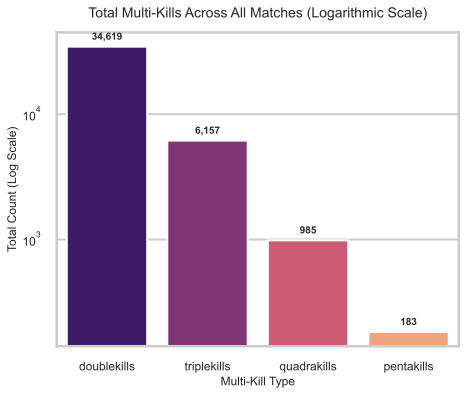

In [18]:
# multi kill distribution
multikill_totals = df[['doublekills', 'triplekills', 'quadrakills', 'pentakills']].sum()

plt.figure(figsize=(7, 6))
sns.barplot(x=multikill_totals.index, y=multikill_totals.values, palette='magma')

plt.yscale('log')

plt.title('Total Multi-Kills Across All Matches (Logarithmic Scale)', fontsize=14, pad=15)
plt.xlabel('Multi-Kill Type', fontsize=12)
plt.ylabel('Total Count (Log Scale)', fontsize=12)

ax = plt.gca()
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height):,}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', 
                    xytext=(0, 5), 
                    textcoords='offset points',
                    fontsize=10, 
                    weight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

/var/folders/jn/2yd4xw3j43l6tt2w0gfb6nh80000gn/T/ipykernel_47198/845256308.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




(array([   0., 2000., 4000., 6000., 8000.]),
 [Text(0, 0.0, '0'),
  Text(0, 2000.0, '2000'),
  Text(0, 4000.0, '4000'),
  Text(0, 6000.0, '6000'),
  Text(0, 8000.0, '8000')])

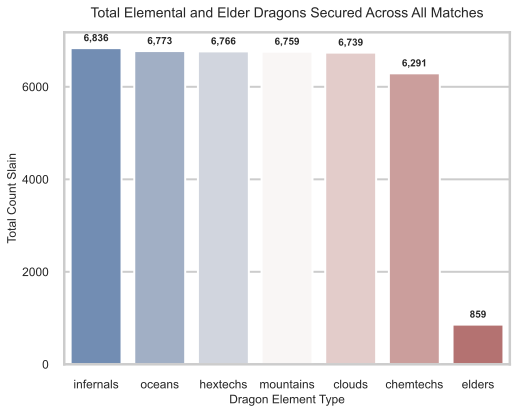

In [19]:
dragon_columns = ['infernals', 'mountains', 'clouds', 'oceans', 'chemtechs', 'hextechs', 'elders']

dragon_totals = df[dragon_columns].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x=dragon_totals.index, y=dragon_totals.values, ax=ax, palette='vlag')

ax.set_title('Total Elemental and Elder Dragons Secured Across All Matches', fontsize=14, pad=15)
ax.set_xlabel('Dragon Element Type', fontsize=12)
ax.set_ylabel('Total Count Slain', fontsize=12)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height):,}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', 
                    xytext=(0, 5), 
                    textcoords='offset points',
                    fontsize=10, 
                    weight='bold')

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

/var/folders/jn/2yd4xw3j43l6tt2w0gfb6nh80000gn/T/ipykernel_47198/2623652568.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




(array([    0., 10000., 20000., 30000., 40000., 50000.]),
 [Text(0, 0.0, '0'),
  Text(0, 10000.0, '10000'),
  Text(0, 20000.0, '20000'),
  Text(0, 30000.0, '30000'),
  Text(0, 40000.0, '40000'),
  Text(0, 50000.0, '50000')])

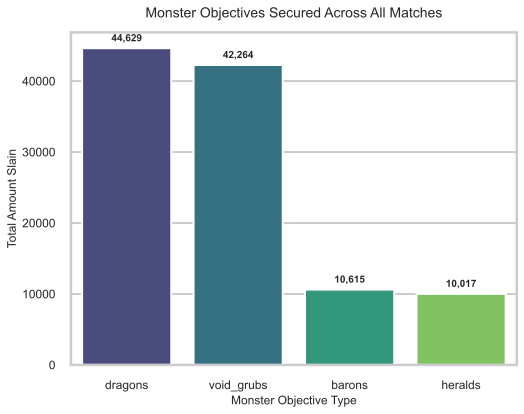

In [20]:
objective_columns = ['dragons', 'heralds', 'barons', 'void_grubs']

objective_totals = df[objective_columns].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x=objective_totals.index, y=objective_totals.values, ax=ax, palette='viridis')

ax.set_title('Monster Objectives Secured Across All Matches', fontsize=14, pad=15)
ax.set_xlabel('Monster Objective Type', fontsize=12)
ax.set_ylabel('Total Amount Slain', fontsize=12)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height):,}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', 
                    xytext=(0, 5), 
                    textcoords='offset points',
                    fontsize=10, 
                    weight='bold')

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

In [21]:
# Bivariate Analysis	

# Analysis in Notebook:
# Look at the statistics of pairs of columns to identify possible associations.
# For instance, you may create scatter plots and plot conditional distributions, or box-plots. 
# You must plot at least two such plots in your notebook. 
# The results of your bivariate analyses will be helpful in identifying interesting hypothesis tests!

# Report on Website:
# Embed at least one plotly plot that displays the relationship between two columns. 
# Include a 1-2 sentence explanation about your plot, making sure to describe and interpret any trends present. 
# (Your notebook will likely have more visualizations than your website, and that’s fine. 
# Feel free to embed more than one bivariate visualization in your website if you’d like, but make sure that each embedded plot is accompanied by a description.

In [27]:
# Total kills by match result
plt.figure(figsize=(7, 7))

fig = px.box(
    df, 
    x='result', 
    y='total_kills', 
    title='Total Kills by Match Result',
    color='result',
    color_discrete_sequence=px.colors.qualitative.Set2 # Uses the same Set2 palette style
)

# Apply your styling and labels
fig.update_layout(
    width=1000,   # Matches your figsize width
    height=800,  # Matches your figsize height
    xaxis_title='Result',
    yaxis_title='Total Kills',
    template='simple_white',
    title_font_size=16,
    xaxis_title_font_size=12,
    yaxis_title_font_size=12,
    showlegend=False # Hides the redundant color legend on the side
)

# Save perfectly to HTML for your Jekyll site
fig.write_html('assets/kills_by_result.html', include_plotlyjs='cdn')

# Display it in your notebook
fig.show()

<Figure size 700x700 with 0 Axes>

In [29]:
# Total monster objectives by match result
fig = px.box(
    df, 
    x='result', 
    y='total_monster_objectives', 
    title='Total Monster Objectives by Match Result',
    color='result',
    color_discrete_sequence=px.colors.qualitative.Set2 # Uses the same Set2 palette style
)

# Apply your styling and labels
fig.update_layout(
    width=1000,   # Matches your figsize width
    height=800,  # Matches your figsize height
    xaxis_title='Result',
    yaxis_title='Total Monster Objectives',
    template='simple_white',
    title_font_size=16,
    xaxis_title_font_size=12,
    yaxis_title_font_size=12,
    showlegend=False # Hides the redundant color legend on the side
)

# Save perfectly to HTML for your Jekyll site
fig.write_html('assets/monster_objectives_by_result.html', include_plotlyjs='cdn')

# Display it in your notebook
fig.show()

In [24]:
#Interesting Aggregates	

# Analysis in Notebook:
# Choose columns to group and pivot by and examine aggregate statistics.

# Report on Website:
# Embed at least one grouped table or pivot table in your website and explain its significance.

In [31]:
# Average kills and objectives by match result

result_summary = df.groupby('result')[[
    'total_kills',
    'total_monster_objectives',
    'dragons',
    'heralds',
    'barons',
    'void_grubs'
]].mean()

result_summary

,total_kills,total_monster_objectives,dragons,heralds,barons,void_grubs
result,,,,,,
0,10.6,3.68,1.41,0.34,0.17,1.77
1,22.0,7.03,3.04,0.66,0.89,2.44


In [35]:
print(result_summary.to_markdown())

|   result |   total_kills |   total_monster_objectives |   dragons |   heralds |   barons |   void_grubs |
|---------:|--------------:|---------------------------:|----------:|----------:|---------:|-------------:|
|        0 |       10.5984 |                     3.6846 |   1.40974 |  0.337617 | 0.171249 |      1.76599 |
|        1 |       21.9984 |                     7.0272 |   3.03626 |  0.660291 | 0.886232 |      2.44441 |


## Step 3: Assessment of Missingness

#### NMAR Analysis

In [36]:
pd.set_option('display.max_rows', None)
df.isnull().sum().sort_values(ascending=False)

mountains                   1634
elders                      1634
hextechs                    1634
chemtechs                   1634
doublekills                 1634
triplekills                 1634
quadrakills                 1634
pentakills                  1634
oceans                      1634
clouds                      1634
infernals                   1634
gameid                         0
barons                         0
void_grubs                     0
heralds                        0
firstblood                     0
dragons                        0
participantid                  0
assists                        0
deaths                         0
total_kills                    0
result                         0
position                       0
side                           0
total_monster_objectives       0
dtype: int64


We believe that there are no columns in the dataset that are NMAR. The null values are either dragon types (mountain, elders, hextechs, chemtechs, oceans, clouds, infernals) and kill types (double, triple, quadra, penta). These values are likely to be dependent on other League of Legends stats, such as the number of dragons killed or the total number of team kills. It is unlikely that the missing values are only dependent on themselves, as they are probably MD, MAR, or MCAR.

#### Missingness Analysis

In this section, we will test if there is a depenency for the null values of the dragon types on the rest of the dataset. For simplicity, we will only be using one dragon type, 'mountains'.

**Null Hypothesis**: The distribution of mountains is independent of another column. Any observed difference in proportions is due to random chance.

**Alternative Hypothesis:** The distribution of mountains depends on another column.

**Test Statistic**: Total Variation Distance (TVD)

In [37]:
def calculate_tvd(data, group_col, category_col):
    distributions = pd.crosstab(data[group_col], data[category_col], normalize='index')
    
    if len(distributions) == 2:
        tvd = distributions.diff().iloc[-1].abs().sum() / 2
    else:
        global_dist = data[category_col].value_counts(normalize=True)
        tvd = (distributions - global_dist).abs().sum(axis=1).max() / 2
        
    return tvd

In [38]:
def run_permutation_test(data, group_col, target_col, n_repetitions=1000, seed=42):
    np.random.seed(seed)
    
    test_df = data[[group_col, target_col]].dropna()
    
    if len(test_df) < 10:
        return None, None
    
    observed_tvd = calculate_tvd(test_df, group_col, target_col)
    
    simulated_tvds = []
    sim_df = test_df.copy()
    
    for _ in range(n_repetitions):
        sim_df['shuffled_group'] = np.random.permutation(sim_df[group_col])
        
        sim_tvd = calculate_tvd(sim_df, 'shuffled_group', target_col)
        simulated_tvds.append(sim_tvd)
        
    p_value = np.mean(np.array(simulated_tvds) >= observed_tvd)
    
    return observed_tvd, p_value

In [39]:
target_column = 'mountains'

ignore_columns = ['gameid', 'participantid', target_column]

results = []

for col in df.columns:
    if col in ignore_columns:
        continue
        
    if df[col].nunique() > 15: 
        continue
        
    obs_tvd, p_val = run_permutation_test(df, group_col=col, target_col=target_column, n_repetitions=1000)
    
    if obs_tvd is not None:
        results.append({
            'Column Tested': col,
            'Observed TVD': round(obs_tvd, 4),
            'p-value': round(p_val, 4),
            'Significant (α=0.05)': 'Yes' if p_val < 0.05 else 'No',
            'Result': 'Reject' if p_val < 0.05 else 'Fail to Reject'
        })

results_df = pd.DataFrame(results).sort_values(by='p-value')
print(results_df.to_string(index=False))

Column Tested  Observed TVD  p-value Significant (α=0.05)         Result
         side          0.06 0.00e+00                  Yes         Reject
      heralds          0.07 0.00e+00                  Yes         Reject
       result          0.16 0.00e+00                  Yes         Reject
   firstblood          0.05 0.00e+00                  Yes         Reject
       clouds          0.28 2.00e-03                  Yes         Reject
     hextechs          0.28 3.00e-03                  Yes         Reject
    chemtechs          0.28 3.00e-03                  Yes         Reject
    infernals          0.28 3.00e-03                  Yes         Reject
       oceans          0.28 5.00e-03                  Yes         Reject
   void_grubs          0.04 5.00e-02                   No Fail to Reject
       barons          0.38 6.70e-02                   No Fail to Reject
      dragons          0.44 1.47e-01                   No Fail to Reject
  doublekills          0.40 2.01e-01               

From these results, we can see that the 'mountains' column is dependent on other columns such as side, heralds, result, firstblood, clouds, hextechs, chemtechs, infernals, and oceans. The 'mountains' column is not dependent on other columns such as void grubs, barons, dragons, doublekills, elders, pentakills, triplekills, quardrakills, and position.

What we found interesting is the the dragon type column is mainly not dependent on the amount of dragons killed, but whether the dragon is another type. This makes sense however, since if the dragon is one type, it will not be of another.

Below is an example of plots for 'mountains' when it is tested against 'result', as well as 'mountains' when it is tested against 'barons.

In [43]:
sns.set_theme(style="whitegrid")
np.random.seed(42)
n_repetitions = 1000

columns_to_plot = ["result", "barons"]
plot_data = {}

for col in columns_to_plot:
    test_df = df[[col, "mountains"]].dropna()

    obs_tvd = calculate_tvd(test_df, col, "mountains")

    simulated_tvds = []
    sim_df = test_df.copy()
    for _ in range(n_repetitions):
        sim_df["shuffled_group"] = np.random.permutation(sim_df[col])
        sim_tvd = calculate_tvd(sim_df, "shuffled_group", "mountains")
        simulated_tvds.append(sim_tvd)

    simulated_tvds = np.array(simulated_tvds)
    p_val = np.mean(simulated_tvds >= obs_tvd)

    plot_data[col] = {
        "obs": obs_tvd,
        "sims": simulated_tvds,
        "p_val": p_val,
    }

import plotly.graph_objects as go

# 1. Create the figure for the 'result' test
fig_result = go.Figure()

# Add the distribution histogram
fig_result.add_trace(
    go.Histogram(
        x=plot_data['result']['sims'],
        name='Null Distribution (Shuffled)',
        marker_color='skyblue',
        opacity=0.6,
        nbinsx=30
    )
)

# Add Observed TVD Line
fig_result.add_vline(
    x=plot_data['result']['obs'],
    line_width=2.5,
    line_dash="dash",
    line_color="red",
    annotation_text=f"Observed TVD ({plot_data['result']['obs']:.4f})",
    annotation_position="top right"
)

# Style the chart
fig_result.update_layout(
    title={
        'text': f"TVD Distribution: mountains vs result<br><sup>(p-value = {plot_data['result']['p_val']:.4e})</sup>",
        'font': {'size': 16}
    },
    xaxis_title="Total Variation Distance (TVD)",
    yaxis_title="Count",
    width=600,
    height=450,
    template='simple_white',
    showlegend=False
)

# Save to your Jekyll assets folder
fig_result.write_html('assets/tvd_mountains_vs_result.html', include_plotlyjs='cdn')

# Display the chart
fig_result.show()

In [44]:
fig_barons = go.Figure()

# Add the distribution histogram
fig_barons.add_trace(
    go.Histogram(
        x=plot_data['barons']['sims'],
        name='Null Distribution (Shuffled)',
        marker_color='skyblue',
        opacity=0.6,
        nbinsx=30
    )
)

# Add Observed TVD Line
fig_barons.add_vline(
    x=plot_data['barons']['obs'],
    line_width=2.5,
    line_dash="dash",
    line_color="red",
    annotation_text=f"Observed TVD ({plot_data['barons']['obs']:.4f})",
    annotation_position="top right"
)

# Style the chart
fig_barons.update_layout(
    title={
        'text': f"TVD Distribution: mountains vs barons<br><sup>(p-value = {plot_data['barons']['p_val']:.4e})</sup>",
        'font': {'size': 16}
    },
    xaxis_title="Total Variation Distance (TVD)",
    yaxis_title="Count",
    width=600,
    height=450,
    template='simple_white',
    showlegend=False
)

# Save to your Jekyll assets folder
fig_barons.write_html('assets/tvd_mountains_vs_barons.html', include_plotlyjs='cdn')

# Display the chart
fig_barons.show()

## Step 4: Hypothesis Testing

In this section, we will run two one-sided permutation tests using difference in means as the test statistic. This helps us compare whether winning or losing teams tend to have higher values for each stat: kills and monster objectives.

#### **Test 1: Kills**

Null Hypothesis:
Winning teams and losing teams have the same distribution of total kills. Any difference in average kills is due to random chance.

Alternative Hypothesis:
Winning teams have a higher mean number of kills than losing teams.

Test statistics: mean kills for winning teams - mean kills for losing teams

In [45]:
np.random.seed(42)
n_repetitions = 5000

df_test1 = df[["result", "total_kills"]].dropna()

mean_win_kills = df_test1.loc[df_test1["result"] == 1, "total_kills"].mean()
mean_loss_kills = df_test1.loc[df_test1["result"] == 0, "total_kills"].mean()
obs_diff_kills = mean_win_kills - mean_loss_kills

sim_diffs_kills = []
sim_df_test1 = df_test1.copy()

for _ in range(n_repetitions):
    shuffled_labels = np.random.permutation(sim_df_test1["result"])
    sim_win = sim_df_test1.loc[shuffled_labels == 1, "total_kills"].mean()
    sim_loss = sim_df_test1.loc[shuffled_labels == 0, "total_kills"].mean()
    sim_diffs_kills.append(sim_win - sim_loss)

sim_diffs_kills = np.array(sim_diffs_kills)
p_val_kills = np.mean(sim_diffs_kills >= obs_diff_kills)


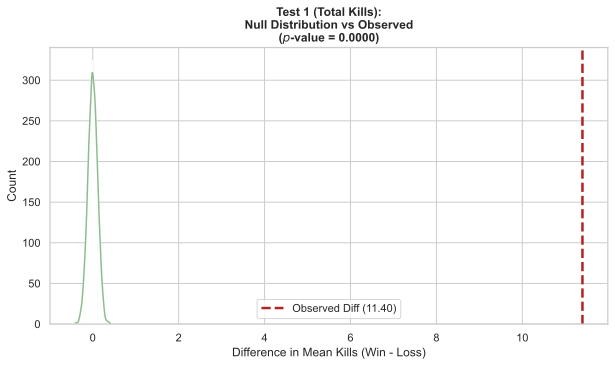

In [48]:
sns.histplot(
    sim_diffs_kills,
    color="darkseagreen",
    kde=True,
    stat="count",
    alpha=0.6,
)
plt.axvline(
    x=obs_diff_kills,
    color="firebrick",
    linestyle="--",
    linewidth=2.5,
    label=f"Observed Diff ({obs_diff_kills:.2f})",
)

plt.title(f"Test 1 (Total Kills):\nNull Distribution vs Observed\n($p$-value = {p_val_kills:.4f})", fontsize=12, fontweight="bold")
plt.xlabel("Difference in Mean Kills (Win - Loss)")
plt.ylabel("Count")
plt.legend()

In [50]:
fig = go.Figure()

# Add the distribution histogram
fig.add_trace(
    go.Histogram(
        x=sim_diffs_kills,
        name='Null Distribution',
        marker_color='darkseagreen',
        opacity=0.6,
        nbinsx=30
    )
)

# Add the Observed vertical line
fig.add_vline(
    x=obs_diff_kills,
    line_width=2.5,
    line_dash="dash",
    line_color="firebrick",
    annotation_text=f"Observed Diff ({obs_diff_kills:.2f})",
    annotation_position="top right"
)

# Apply matching styling, titles, and fonts
fig.update_layout(
    title={
        'text': f"Test 1 (Total Kills): Null Distribution vs Observed<br><sup>(p-value = {p_val_kills:.4f})</sup>",
        'font': {'size': 14, 'weight': 'bold'}
    },
    xaxis_title="Difference in Mean Kills (Win - Loss)",
    yaxis_title="Count",
    template='simple_white',
    showlegend=False
)

# Save the interactive HTML file to your assets folder
fig.write_html('assets/test1_total_kills.html', include_plotlyjs='cdn')

# Display inside your Jupyter notebook
fig.show()

Since the p-value (0.0) is less than the 0.05 significance level, we reject the null hypothesis. There is sufficient evidence that winning teams have a higher mean total kills than losing teams.

#### **Test 2: Monster Objectives**

Null Hypothesis:
Winning teams and losing teams have the same distribution of monster objectives. Any difference in average monster objectives is due to random chance.

Alternative Hypothesis:
Winning teams have a higher average number of monster objectives than losing teams.

Test statistics: mean monster objectives for winning teams - mean monster objectives for losing teams

In [52]:
np.random.seed(42)
n_repetitions = 5000

df_test2 = df[["result", "total_monster_objectives"]].dropna()

mean_win_monst = df_test2.loc[df_test2["result"] == 1, "total_monster_objectives"].mean()
mean_loss_monst = df_test2.loc[df_test2["result"] == 0, "total_monster_objectives"].mean()
obs_diff_monsters = mean_win_monst - mean_loss_monst

sim_diffs_monsters = []
sim_df_test2 = df_test2.copy()

for _ in range(n_repetitions):
    # Permute the group labels
    shuffled_labels = np.random.permutation(sim_df_test2["result"])
    sim_win = sim_df_test2.loc[
        shuffled_labels == 1, "total_monster_objectives"
    ].mean()
    sim_loss = sim_df_test2.loc[
        shuffled_labels == 0, "total_monster_objectives"
    ].mean()
    sim_diffs_monsters.append(sim_win - sim_loss)

sim_diffs_monsters = np.array(sim_diffs_monsters)
p_val_monsters = np.mean(sim_diffs_monsters >= obs_diff_monsters)

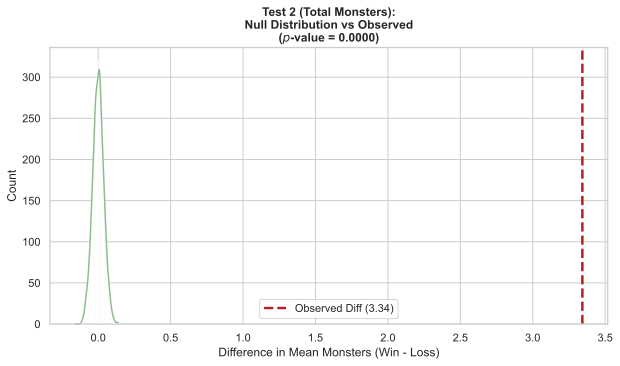

In [53]:
sns.histplot(
    sim_diffs_monsters,
    color="darkseagreen",
    kde=True,
    stat="count",
    alpha=0.6,
)
plt.axvline(
    x=obs_diff_monsters,
    color="firebrick",
    linestyle="--",
    linewidth=2.5,
    label=f"Observed Diff ({obs_diff_monsters:.2f})",
)

plt.title(f"Test 2 (Total Monsters):\nNull Distribution vs Observed\n($p$-value = {p_val_monsters:.4f})", fontsize=12, fontweight="bold")
plt.xlabel("Difference in Mean Monsters (Win - Loss)")
plt.ylabel("Count")
plt.legend()

In [55]:
fig = go.Figure()

# Add the distribution histogram
fig.add_trace(
    go.Histogram(
        x=sim_diffs_monsters,
        name='Null Distribution',
        marker_color='darkseagreen',
        opacity=0.6,
        nbinsx=30
    )
)

# Add the Observed vertical line
fig.add_vline(
    x=obs_diff_monsters,
    line_width=2.5,
    line_dash="dash",
    line_color="firebrick",
    annotation_text=f"Observed Diff ({obs_diff_monsters:.2f})",
    annotation_position="top right"
)

# Apply matching styling, titles, and fonts
fig.update_layout(
    title={
        'text': f"Test 2 (Total Monsters): Null Distribution vs Observed<br><sup>(p-value = {p_val_monsters:.4f})</sup>",
        'font': {'size': 14, 'weight': 'bold'}
    },
    xaxis_title="Difference in Mean Monsters (Win - Loss)",
    yaxis_title="Count",
    template='simple_white',
    showlegend=False
)

# Save the interactive HTML file to your assets folder
fig.write_html('assets/test2_total_monsters.html', include_plotlyjs='cdn')

# Display inside your Jupyter notebook
fig.show()

Since the p-value (0.0) is less than the 0.05 significance level, we reject the null hypothesis. There is sufficient evidence that winning teams have a higher mean monster objectives than losing teams.

Now that we know that there is a significant difference between winning and losing team's total kills and monster objective, we can try to see which stat will be a better predictor for if a team wins or loses.

## Step 5: Framing a Prediction Problem

Our prediction problem is to predict whether a team wins or loses a match using kills and monster-objective statistics. The response variable is "result" column, where 1 means the team won and 0 means the team lost. Since the response variable has two possible values, this is a binary classification problem.

This prediction problem connects to our research question because we are comparing whether kills or monster objectives have more impact on match outcomes. In our hypothesis tests, we tested whether winning teams tend to have higher total kills and higher total monster objectives than losing teams. In the prediction section, we will use these same types of statistics to predict whether a team won.

The time of prediction is after the match has ended, when team-level statistics such as "total_kills", "dragons", "heralds", "barons", and "void_grubs" are available. Our model uses stats from after the game, so it is not trying to predict the winner before the match starts. It is used to see how closely kills and monster objectives are related to the final result.

We will evaluate our model using accuracy. Accuracy is appropriate because this is a binary classification problem and the response variable is balanced: each match has one winning team and one losing team. Therefore, accuracy gives a clear measure of the proportion of team results that the model correctly predicts.

In [35]:
# Check class balance for the response variable.
df['result'].value_counts(normalize = True)

result
0    0.5
1    0.5
Name: proportion, dtype: float64

In [36]:
# Define features and response variable for prediction.
features = ['total_kills', 'dragons', 'heralds', 'barons', 'void_grubs']

X = df[features]
y = df['result']

X.head()

,total_kills,dragons,heralds,barons,void_grubs
0,3,0.0,0.0,0.0,0.0
1,13,2.0,1.0,1.0,6.0
2,21,3.0,1.0,1.0,6.0
3,10,2.0,0.0,0.0,0.0
4,18,0.0,0.0,0.0,2.0


## Step 6: Baseline Model

For our baseline models, we used logistic regression to predict whether a team won or lost. The features used were "total_kills" and "total_monster_objectives". All of these features are quantitative because they are numeric counts of team kills or monster objectives.

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Select baseline features and response variable.
baseline_features = ['total_kills']

X = df[baseline_features]
y = df['result']

# Split data into training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.25, 
    random_state=42, 
    stratify=y
)

# Create baseline model pipeline.
baseline_model = Pipeline([
    ('model', LogisticRegression(max_iter=1000))
])

# Fit model on training data.
baseline_model.fit(X_train, y_train)

# Predict on test data.
y_pred = baseline_model.predict(X_test)

# Evaluate model accuracy.
baseline_accuracy = baseline_model.score(X_test, y_test)
baseline_accuracy

0.8386132695756127

In [38]:
 # featureed engineered new column: df['dragons'] + df['heralds'] + df['barons'] + df['void_grubs']
baseline_features = ['total_monster_objectives']

X = df[baseline_features]
y = df['result']

# Split data into training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.25, 
    random_state=42, 
    stratify=y
)

# Create baseline model pipeline.
baseline_model = Pipeline([
    ('model', LogisticRegression(max_iter=1000))
])

# Fit model on training data.
baseline_model.fit(X_train, y_train)

# Predict on test data.
y_pred = baseline_model.predict(X_test)

# Evaluate model accuracy.
baseline_accuracy = baseline_model.score(X_test, y_test)
baseline_accuracy

0.7728631201434548

In [39]:
baseline_features = ['total_kills', 'total_monster_objectives']

X = df[baseline_features]
y = df['result']

# Split data into training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.25, 
    random_state=42, 
    stratify=y
)

# Create baseline model pipeline.
baseline_model = Pipeline([
    ('model', LogisticRegression(max_iter=1000))
])

# Fit model on training data.
baseline_model.fit(X_train, y_train)

# Predict on test data.
y_pred = baseline_model.predict(X_test)

# Evaluate model accuracy.
baseline_accuracy = baseline_model.score(X_test, y_test)
baseline_accuracy

0.8732815301852959

Our baseline logistic regression model for the kills statistic achieved an accuracy of approximately 0.8436, meaning it correctly predicted about 84.36% of team match results in the unseen test set. For the monster objective statistic, the model achieved an accuracy of 77.75%. The model using both features, however, had a higher accuracy of 87.51%.

This suggests that the baseline model is performing well, especially because the response variable is balanced between wins and losses. Since the model only uses kill and monster-objective count features, this accuracy also suggests that these statistics are strongly connected to match outcomes.

We believe this is a good baseline model because it performs much better than a simple classifier that always predicts the majority class. Since the `result` column is balanced, a majority-class baseline would only achieve about 50% accuracy. Our two model's accuracy is much higher than that, so it provides a strong starting point for predicting match outcomes.


## Step 7: Final Model

To determine the best model for the two statistics, we will be using the SequentialFeatureSelector to determine which features are most helpful for the model. We will also use GridSearchCV to compare using a Logistic Regession, SVC (Support Vector Classifier), and Decision Tree Classifier for the final model, as well as testing different hyperparameters for them. In the Pipeline, we decided to use StandardScalar on all the columns to make all the columns standardized. Finally, this time we used the ROC-AUC score to evaluate the models since it tends to be a better evaluator for binary classifcation models.

In [40]:
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier

#### Final Model for Kills Statistic

In [41]:
df = df.copy().dropna() # for final model, remove any rows with missing data

features = ['total_kills', 'doublekills', 'triplekills', 'quadrakills', 'pentakills']

X = df[features]
y = df['result']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.25, 
    random_state=42, 
    stratify=y
)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SequentialFeatureSelector(estimator=LogisticRegression(), direction='forward')),
    ('classifier', LogisticRegression()) # Default placeholder
])

param_grid = [
    {
        # SFS Parameter Tuning
        'selector__n_features_to_select': [2, 3, 4], 
        'selector__estimator': [LogisticRegression(max_iter=1000)], # SFS needs an internal model to evaluate features
        
        # Model 1: Logistic Regression Tuning
        'classifier': [LogisticRegression(max_iter=1000)],
        'classifier__C': [0.01, 0.1, 1.0, 10.0],
        'classifier__penalty': ['l2']
    },
    {
        # SFS Parameter Tuning
        'selector__n_features_to_select': [2, 3, 4],
        'selector__estimator': [LogisticRegression(max_iter=1000)],
        
        # Model 2: Support Vector Classifier (SVC) Tuning
        'classifier': [SVC()],
        'classifier__C': [0.1, 1.0, 10.0],
        'classifier__kernel': ['rbf', 'linear']
    },

    {
        'selector__n_features_to_select': [2, 3, 4],
        'selector__estimator': [LogisticRegression(max_iter=1000)],
        
        # Model 3: Decision Tree Classifier Tuning
        'classifier': [DecisionTreeClassifier(random_state=42)],
        'classifier__max_depth': [3, 5, 7, None],          
        'classifier__criterion': ['gini', 'entropy'],      
        'classifier__min_samples_split': [2, 5, 10]    
    }
]

grid_search = GridSearchCV(
    estimator=pipeline, 
    param_grid=param_grid, 
    cv=5, 
    scoring='roc_auc', 
    n_jobs=-1, 
    verbose=1
)

print("Starting grid search with feature selection...")
grid_search.fit(X_train, y_train)

print("\n=== Best Model Results ===")
print(f"Best CV ROC-AUC Score: {grid_search.best_score_:.4f}")
print(f"Best Parameters: \n{grid_search.best_params_}\n")

best_kills_model = grid_search.best_estimator_
selected_mask = best_kills_model.named_steps['selector'].get_support()
selected_features = np.array(features)[selected_mask]

print(f"Features selected by the best model: {selected_features}")

test_score = grid_search.score(X_test, y_test)
print(f"Test Set ROC-AUC Score: {test_score:.4f}")

Starting grid search with feature selection...
Fitting 5 folds for each of 102 candidates, totalling 510 fits

=== Best Model Results ===
Best CV ROC-AUC Score: 0.9250
Best Parameters: 
{'classifier': LogisticRegression(max_iter=1000), 'classifier__C': 0.01, 'classifier__penalty': 'l2', 'selector__estimator': LogisticRegression(max_iter=1000), 'selector__n_features_to_select': 4}

Features selected by the best model: ['total_kills' 'doublekills' 'quadrakills' 'pentakills']
Test Set ROC-AUC Score: 0.9239


For the kills statistic, the best model was a Logistic Regression model with the hyperparemeters C=0.01. It selected 4 features to use, ['total_kills' 'doublekills' 'quadrakills' 'pentakills'], and ultimately ended up with an ROC-AUC score of 0.9239.

#### Final Model for Monster Objective Statistic

In [42]:
features = ['total_monster_objectives', 'dragons', 'heralds', 'barons', 'void_grubs']

X = df[features]
y = df['result']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.25, 
    random_state=42, 
    stratify=y
)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SequentialFeatureSelector(estimator=LogisticRegression(), direction='forward')),
    ('classifier', LogisticRegression()) # Default placeholder
])

param_grid = [
    {
        # SFS Parameter Tuning
        'selector__n_features_to_select': [2, 3, 4], 
        'selector__estimator': [LogisticRegression(max_iter=1000)], # SFS needs an internal model to evaluate features
        
        # Model 1: Logistic Regression Tuning
        'classifier': [LogisticRegression(max_iter=1000)],
        'classifier__C': [0.01, 0.1, 1.0, 10.0],
        'classifier__penalty': ['l2']
    },
    {
        # SFS Parameter Tuning
        'selector__n_features_to_select': [2, 3, 4],
        'selector__estimator': [LogisticRegression(max_iter=1000)],
        
        # Model 2: Support Vector Classifier (SVC) Tuning
        'classifier': [SVC()],
        'classifier__C': [0.1, 1.0, 10.0],
        'classifier__kernel': ['rbf', 'linear']
    },

    {
        'selector__n_features_to_select': [2, 3, 4],
        'selector__estimator': [LogisticRegression(max_iter=1000)],
        
        # Model 3: Decision Tree Classifier Tuning
        'classifier': [DecisionTreeClassifier(random_state=42)],
        'classifier__max_depth': [3, 5, 7, None],          
        'classifier__criterion': ['gini', 'entropy'],      
        'classifier__min_samples_split': [2, 5, 10]    
    }
]

grid_search = GridSearchCV(
    estimator=pipeline, 
    param_grid=param_grid, 
    cv=5, 
    scoring='roc_auc', 
    n_jobs=-1, 
    verbose=1
)

print("Starting grid search with feature selection...")
grid_search.fit(X_train, y_train)

print("\n=== Best Model Results ===")
print(f"Best CV ROC-AUC Score: {grid_search.best_score_:.4f}")
print(f"Best Parameters: \n{grid_search.best_params_}\n")

best_monsters_model = grid_search.best_estimator_
selected_mask = best_monsters_model.named_steps['selector'].get_support()
selected_features = np.array(features)[selected_mask]

print(f"Features selected by the best model: {selected_features}")

test_score = grid_search.score(X_test, y_test)
print(f"Test Set ROC-AUC Score: {test_score:.4f}")

Starting grid search with feature selection...
Fitting 5 folds for each of 102 candidates, totalling 510 fits

=== Best Model Results ===
Best CV ROC-AUC Score: 0.9183
Best Parameters: 
{'classifier': DecisionTreeClassifier(random_state=42), 'classifier__criterion': 'gini', 'classifier__max_depth': None, 'classifier__min_samples_split': 10, 'selector__estimator': LogisticRegression(max_iter=1000), 'selector__n_features_to_select': 3}

Features selected by the best model: ['total_monster_objectives' 'barons' 'void_grubs']
Test Set ROC-AUC Score: 0.9134


For the monster objective statistic, the best model was a Decision Tree Classifier model with the hyperparameters Max Depth=None, samplessplit=10, criterion=gini. It selected 3 features to use, ['total_monster_objectives' 'barons' 'void_grubs'], and had a final ROC-AUC score of 0.9124.

In [43]:
features = ['total_monster_objectives', 'dragons', 'heralds', 'barons', 'void_grubs', 'total_kills', 'doublekills', 'triplekills', 'quadrakills', 'pentakills']

X = df[features]
y = df['result']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.25, 
    random_state=42, 
    stratify=y
)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SequentialFeatureSelector(estimator=LogisticRegression(), direction='forward')),
    ('classifier', LogisticRegression()) # Default placeholder
])

param_grid = [
    {
        # SFS Parameter Tuning
        'selector__n_features_to_select': [2, 3, 4, 5, 6, 7, 8, 9, 10], 
        'selector__estimator': [LogisticRegression(max_iter=1000)], # SFS needs an internal model to evaluate features
        
        # Model 1: Logistic Regression Tuning
        'classifier': [LogisticRegression(max_iter=1000)],
        'classifier__C': [0.01, 0.1, 1.0, 10.0],
        'classifier__penalty': ['l2']
    },
    {
        # SFS Parameter Tuning
        'selector__n_features_to_select': [2, 3, 4, 5, 6, 7, 8, 9, 10],
        'selector__estimator': [LogisticRegression(max_iter=1000)],
        
        # Model 2: Support Vector Classifier (SVC) Tuning
        'classifier': [SVC()],
        'classifier__C': [0.1, 1.0, 10.0],
        'classifier__kernel': ['rbf', 'linear']
    },

    {
        'selector__n_features_to_select': [2, 3, 4, 5, 6, 7, 8, 9, 10],
        'selector__estimator': [LogisticRegression(max_iter=1000)],
        
        # Model 3: Decision Tree Classifier Tuning
        'classifier': [DecisionTreeClassifier(random_state=42)],
        'classifier__max_depth': [3, 5, 7, None],          
        'classifier__criterion': ['gini', 'entropy'],      
        'classifier__min_samples_split': [2, 5, 10]    
    }
]

grid_search = GridSearchCV(
    estimator=pipeline, 
    param_grid=param_grid, 
    cv=5, 
    scoring='roc_auc', 
    n_jobs=-1, 
    verbose=1
)

print("Starting grid search with feature selection...")
grid_search.fit(X_train, y_train)

print("\n=== Best Model Results ===")
print(f"Best CV ROC-AUC Score: {grid_search.best_score_:.4f}")
print(f"Best Parameters: \n{grid_search.best_params_}\n")

best_pipeline = grid_search.best_estimator_
selected_mask = best_pipeline.named_steps['selector'].get_support()
selected_features = np.array(features)[selected_mask]

print(f"Features selected by the best model: {selected_features}")

test_score = grid_search.score(X_test, y_test)
print(f"Test Set ROC-AUC Score: {test_score:.4f}")

Starting grid search with feature selection...
Fitting 5 folds for each of 306 candidates, totalling 1530 fits


KeyboardInterrupt: 

Just for comparision, we also created a model using both features from the kills and monster objective statistics. The best model was a Logistic Regression Model with the hyperparameter C=10. It selected 9 features to use, and had a final ROC-AUC Score of 0.9522. 

#### Model Intepretations 

In conclusion, the kills statistics final model had a higher ROC-AUC score of 0.9239 using a Logistic Regression model. Compared to its baseline model, the kills statistic model had a ROC-AUC score of 0.8436 using a simple Logistic Regression model. The final model wa thus improved by 0.0803, or about 8.03%. On the other hand, the monster objective statistics final model had a lower ROC-AUC score of 0.9124 using a Decision Tree model. It's original baseline LogisticRegression model has a ROC-AUC score of 0.7775, meanig that it approved by 0.1349, or 13.49%. Lastly, the the model using both features  , had a final ROC-AUC score 0f 0.9522. The original baseline model using only the total_kills and total_monster_objectives, however, had a  accuracy of 0.8751. Thus this model improvd by 0.0771 or 7.71%. All three models were able to improve significantly and are highly accurate in it's prediction of if a team wins or loses a match. 


It appears that the kills statistic model was a better predictor for the result of the match. It's final model was higher than the monster objectives model by 1.15%. While this suggest that the kills statistic has higher predictive power, the small margin of difference indicates that both statistics are important factors and predictors of a match's result. 


## Step 8: Fairness Analysis

In [ ]:
## final model variables:
## for kills - best_kills_model
## for monsters - best_monsters_model